Training samples: 48, Test samples: 12
Epoch 1/20
2/2 [==============================] - 1s 282ms/step - loss: 0.2053 - val_loss: 0.5362
Epoch 2/20
2/2 [==============================] - 0s 50ms/step - loss: 0.1747 - val_loss: 0.4680
Epoch 3/20
2/2 [==============================] - 0s 44ms/step - loss: 0.1469 - val_loss: 0.4046
Epoch 4/20
2/2 [==============================] - 0s 43ms/step - loss: 0.1226 - val_loss: 0.3464
Epoch 5/20
2/2 [==============================] - 0s 40ms/step - loss: 0.1006 - val_loss: 0.2938
Epoch 6/20
2/2 [==============================] - 0s 40ms/step - loss: 0.0815 - val_loss: 0.2468
Epoch 7/20
2/2 [==============================] - 0s 39ms/step - loss: 0.0641 - val_loss: 0.2054
Epoch 8/20
2/2 [==============================] - 0s 50ms/step - loss: 0.0511 - val_loss: 0.1689
Epoch 9/20
2/2 [==============================] - 0s 50ms/step - loss: 0.0395 - val_loss: 0.1376
Epoch 10/20
2/2 [==============================] - 0s 127ms/step - loss: 0.0303 - val_l

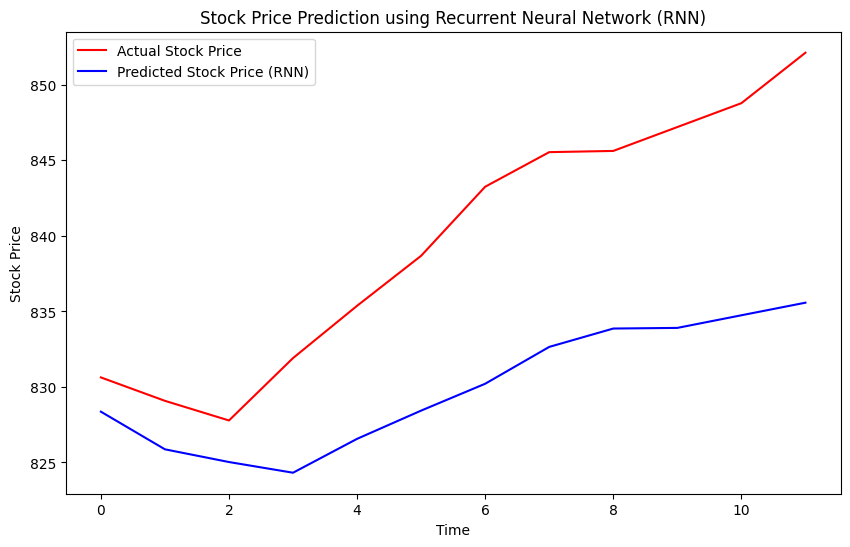

RMSE: 10.7430


In [16]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import SimpleRNN, Dense

# Load the data
df = pd.read_csv('GOOG.csv')

# Ensure datetime format and set index
df['Date'] = pd.to_datetime(df['Date'])
df.set_index('Date', inplace=True)

# Focus on 'Close' prices
data = df[['Close']].values

# Normalize the data
scaler = MinMaxScaler(feature_range=(0, 1))
scaled_data = scaler.fit_transform(data)

# Create time-series sequences
def create_sequences(dataset, time_steps=60):
    X, y = [], []
    for i in range(len(dataset) - time_steps):
        X.append(dataset[i:i+time_steps])
        y.append(dataset[i+time_steps])
    return np.array(X), np.array(y)

# Set time_steps lower if dataset is small
time_steps = 1

X, y = create_sequences(scaled_data, time_steps)

if len(X) == 0:
    raise ValueError("Not enough data. Try reducing time_steps or using more rows in your CSV.")

# Train/test split
split = int(0.8 * len(X))
X_train, X_test = X[:split], X[split:]
y_train, y_test = y[:split], y[split:]

print(f"Training samples: {X_train.shape[0]}, Test samples: {X_test.shape[0]}")

# Build the Simple RNN model
model = Sequential()
model.add(SimpleRNN(units=50, activation='tanh', input_shape=(time_steps, 1)))
model.add(Dense(units=1))  # Output layer

# Compile the model
model.compile(optimizer='adam', loss='mean_squared_error')

# Train the model
model.fit(X_train, y_train, epochs=20, batch_size=32, validation_data=(X_test, y_test))

# Predict on test data
predicted = model.predict(X_test)

# Inverse scale predictions and true values
predicted = scaler.inverse_transform(predicted)
y_test_inv = scaler.inverse_transform(y_test)

# Plot results
plt.figure(figsize=(10, 6))
plt.plot(y_test_inv, color='red', label='Actual Stock Price')
plt.plot(predicted, color='blue', label='Predicted Stock Price (RNN)')
plt.title('Stock Price Prediction using Recurrent Neural Network (RNN)')
plt.xlabel('Time')
plt.ylabel('Stock Price')
plt.legend()
plt.show()

# Evaluate
from sklearn.metrics import mean_squared_error
rmse = np.sqrt(mean_squared_error(y_test_inv, predicted))
print(f'RMSE: {rmse:.4f}')
